# Marketing Campaign Performance & ROI Optimization Analytics

### Business Problem

ompanies running multi-channel marketing campaigns often struggle to identify which campaign types, marketing channels, and audience segments generate the highest engagement and return on investment. Inefficient campaign strategies and poor budget allocation can reduce marketing effectiveness and profitability. This project aims to analyze marketing campaign performance data to identify high-performing campaigns, evaluate engagement and conversion efficiency, and provide data-driven recommendations for improving marketing ROI.

### Business Objectives
1. Analyze campaign performance across different marketing channels and campaign types.
2. Evaluate audience engagement and conversion efficiency across customer segments.
3. Identify high-performing and underperforming campaigns using ROI and engagement metrics.
4. Provide recommendations for optimizing marketing effectiveness and campaign profitability.

### Key Business Questions
1. Which marketing channels generate the highest ROI and engagement performance?
2. Which campaign types achieve strong engagement but weaker conversion efficiency?
3. Which target audience and customer segments respond most effectively to campaigns?
4. Does higher acquisition cost lead to better campaign ROI and conversion performance?
5. Which campaigns should be scaled, optimized, or discontinued based on overall performance?

### Core KPIs
1. Impressions
2. Clicks
3. CTR (Click Through Rate)
4. Conversion Rate
5. Acquisition Cost (CAC)
6. ROI (Return on Investment)
7. Engagement Score

### Dataset Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
df = pd.read_csv("marketing_campaign_dataset.csv")

In [3]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [4]:
df.shape

(200000, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [6]:
df.columns

Index(['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience',
       'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement_Score', 'Customer_Segment', 'Date'],
      dtype='object')

In [7]:
df.columns = df.columns.str.replace('_', ' ')

In [8]:
df.columns

Index(['Campaign ID', 'Company', 'Campaign Type', 'Target Audience',
       'Duration', 'Channel Used', 'Conversion Rate', 'Acquisition Cost',
       'ROI', 'Location', 'Language', 'Clicks', 'Impressions',
       'Engagement Score', 'Customer Segment', 'Date'],
      dtype='object')

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df['Acquisition Cost'] = (
    df['Acquisition Cost']
    .str.replace('$', '')
    .str.replace(',', '')
    .astype(float)
)

In [11]:
df['Duration'] = (
    df['Duration']
    .str.replace('days', ' ' )
    .astype(int)
)

In [12]:
df.dtypes

Campaign ID                  int64
Company                     object
Campaign Type               object
Target Audience             object
Duration                     int64
Channel Used                object
Conversion Rate            float64
Acquisition Cost           float64
ROI                        float64
Location                    object
Language                    object
Clicks                       int64
Impressions                  int64
Engagement Score             int64
Customer Segment            object
Date                datetime64[ns]
dtype: object

In [13]:
df.isnull().sum()

Campaign ID         0
Company             0
Campaign Type       0
Target Audience     0
Duration            0
Channel Used        0
Conversion Rate     0
Acquisition Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement Score    0
Customer Segment    0
Date                0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,Campaign ID,Duration,Conversion Rate,Acquisition Cost,ROI,Clicks,Impressions,Engagement Score,Date
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000
mean,100000.500000,37.503975,0.080070,12504.393040,5.002438,549.772030,5507.301520,5.494710,2021-07-01 23:35:09.600000
min,1.000000,15.000000,0.010000,5000.000000,2.000000,100.000000,1000.000000,1.000000,2021-01-01 00:00:00
25%,50000.750000,30.000000,0.050000,8739.750000,3.500000,325.000000,3266.000000,3.000000,2021-04-02 00:00:00
50%,100000.500000,30.000000,0.080000,12496.500000,5.010000,550.000000,5517.500000,5.000000,2021-07-02 00:00:00
75%,150000.250000,45.000000,0.120000,16264.000000,6.510000,775.000000,7753.000000,8.000000,2021-10-01 00:00:00
max,200000.000000,60.000000,0.150000,20000.000000,8.000000,1000.000000,10000.000000,10.000000,2021-12-31 00:00:00
std,57735.171256,16.746720,0.040602,4337.664545,1.734488,260.019056,2596.864286,2.872581,NaN


### Feature Engineering

In [16]:
df['CTR'] = (df['Clicks']/ df['Impressions'])*100

In [17]:
df[['Clicks','Impressions','CTR']].head()

,Clicks,Impressions,CTR
0,506,1922,26.326743
1,116,7523,1.541938
2,584,7698,7.586386
3,217,1820,11.923077
4,379,4201,9.021662


### Exploratory Data Analysis

### Q1. Which marketing channels generate the highest ROI and engagement performance?

In [18]:
channel_performance = df.groupby('Channel Used')[
    ['ROI','Engagement Score']
].mean().round(2)

In [19]:
channel_performance

,ROI,Engagement Score
Channel Used,,
Email,5.00,5.49
Facebook,5.02,5.50
Google Ads,5.00,5.49
Instagram,4.99,5.49
Website,5.01,5.51
YouTube,4.99,5.48


### Insight:
Marketing channels demonstrated relatively similar average ROI and engagement performance, with Facebook and Website channels showing marginally stronger results compared to other platforms.

In [20]:
channel_detailed = df.groupby('Channel Used')[
    ['ROI','Engagement Score','CTR','Conversion Rate','Acquisition Cost']
].mean().round(2)

In [21]:
channel_detailed

,ROI,Engagement Score,CTR,Conversion Rate,Acquisition Cost
Channel Used,,,,,
Email,5.00,5.49,14.05,0.08,12526.39
Facebook,5.02,5.50,14.05,0.08,12510.90
Google Ads,5.00,5.49,13.92,0.08,12528.03
Instagram,4.99,5.49,14.00,0.08,12491.76
Website,5.01,5.51,14.10,0.08,12487.81
YouTube,4.99,5.48,14.12,0.08,12481.39


### Inisght:
Channel performance remains relatively consistent across platforms, with only marginal differences observed in ROI, engagement, and conversion efficiency metrics.

<Axes: xlabel='Channel Used'>

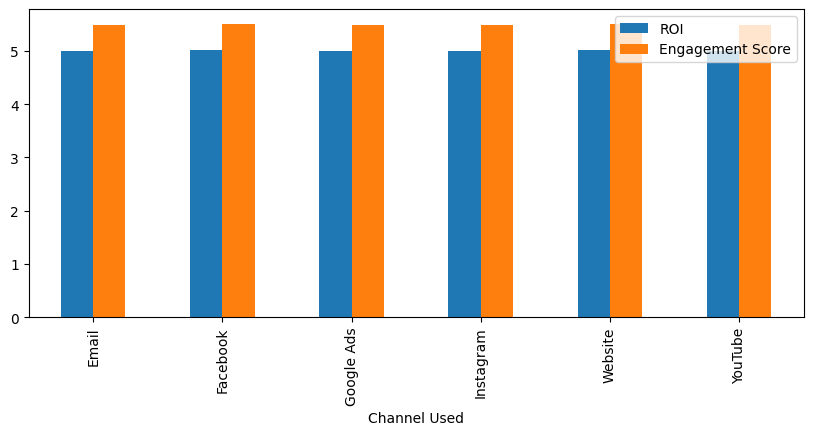

In [22]:
channel_performance[['ROI','Engagement Score']].plot(
    kind='bar',
    figsize=(10,4)
)

### Inisght:
Marketing channels demonstrated relatively consistent ROI and engagement performance, with Website and Facebook channels showing marginally stronger results compared to other platforms.

### Q2. Which campaign types achieve strong engagement but weaker conversion efficiency?

In [23]:
campaign_analysis = df.groupby('Campaign Type')[
    ['Conversion Rate','Engagement Score']
].mean().round(2)

In [24]:
campaign_analysis

,Conversion Rate,Engagement Score
Campaign Type,,
Display,0.08,5.51
Email,0.08,5.50
Influencer,0.08,5.48
Search,0.08,5.49
Social Media,0.08,5.50


<Axes: title={'center': 'Engagement and Conversion Rate by Campaign Type'}, xlabel='Campaign Type'>

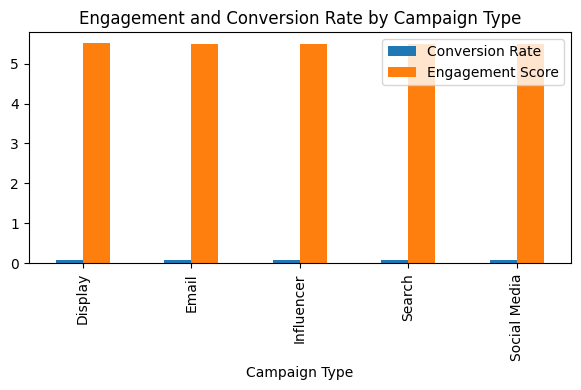

In [25]:
campaign_analysis.plot(
    kind='bar',
    figsize=(7,3),
    title = 'Engagement and Conversion Rate by Campaign Type'
)

### Inisght:
Campaign types demonstrated highly consistent conversion efficiency across all marketing formats, with only marginal differences observed in engagement performance. Display and Email campaigns showed slightly stronger engagement scores, while overall conversion rates remained relatively stable across campaign types. This suggests that campaign format alone may not be a major driver of conversion efficiency within the current dataset.

### Q3. Which target audience and customer segments respond most effectively to campaigns?

In [26]:
segment_analysis = df.groupby('Customer Segment')[
    ['ROI','Engagement Score','Conversion Rate']
].mean().round(2)


In [27]:
segment_analysis

,ROI,Engagement Score,Conversion Rate
Customer Segment,,,
Fashionistas,5.0,5.49,0.08
Foodies,5.0,5.51,0.08
Health & Wellness,5.0,5.48,0.08
Outdoor Adventurers,5.0,5.50,0.08
Tech Enthusiasts,5.0,5.49,0.08


<Axes: title={'center': 'Customer Segment Performance'}, xlabel='Customer Segment'>

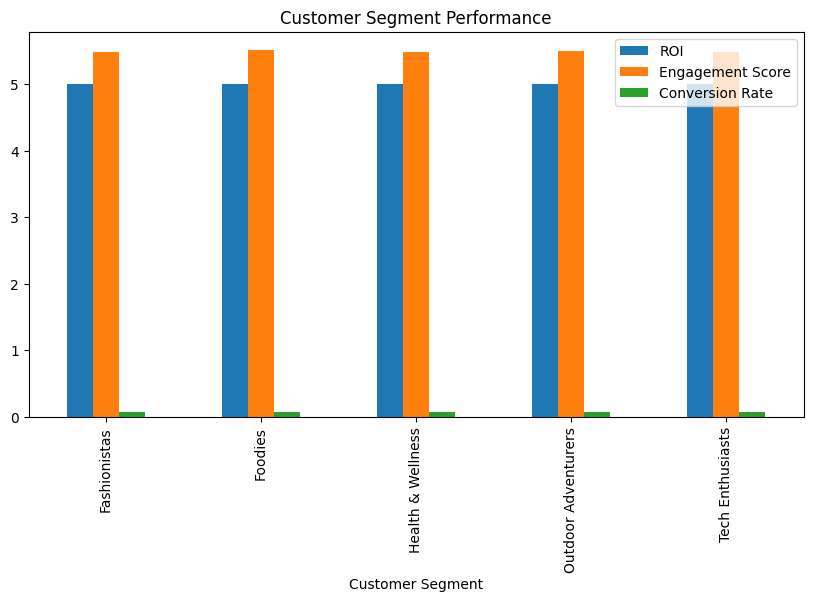

In [76]:
segment_analysis.plot(
    kind='bar',
    figsize=(10,5),
    title = 'Customer Segment Performance'
)

In [29]:
audience_analysis = df.groupby('Target Audience')[
    ['ROI','Engagement Score','Conversion Rate']
].mean().round(2)

In [30]:
audience_analysis

,ROI,Engagement Score,Conversion Rate
Target Audience,,,
All Ages,5.01,5.49,0.08
Men 18-24,4.98,5.52,0.08
Men 25-34,5.02,5.49,0.08
Women 25-34,5.00,5.49,0.08
Women 35-44,5.01,5.49,0.08


<Axes: title={'center': 'Target Audience Performance'}, xlabel='Target Audience'>

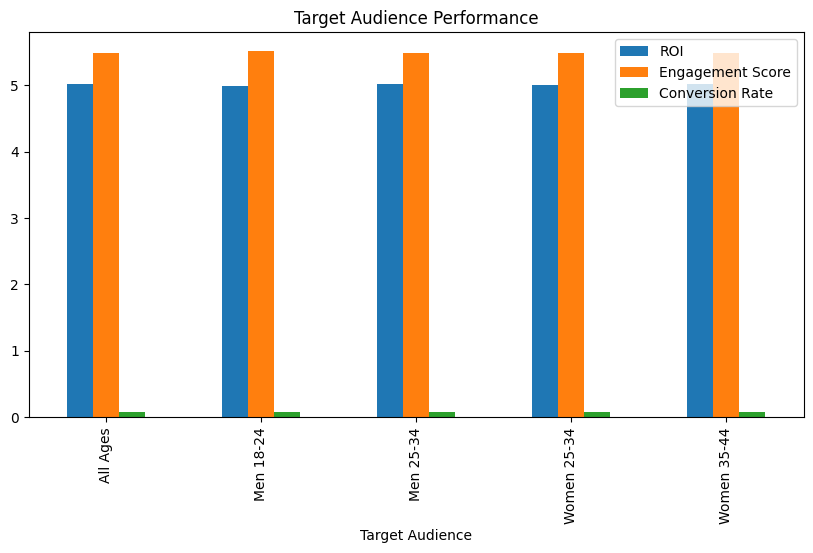

In [75]:
audience_analysis.plot(
    kind='bar',
    figsize=(10,5),
    title='Target Audience Performance'
)

### Inisght:
Customer segments and target audiences demonstrated relatively similar campaign performance across ROI, engagement, and conversion metrics. Foodies and Men 18–24 audiences showed marginally stronger engagement performance, while Men 25–34 audiences achieved slightly higher ROI. Overall, the results suggest that campaign effectiveness remained broadly consistent across audience groups within the dataset.

### Q4. Does higher acquisition cost lead to better campaign ROI and conversion performance?

In [32]:
df[['Acquisition Cost','ROI','Conversion Rate']].describe()

,Acquisition Cost,ROI,Conversion Rate
count,200000.000000,200000.000000,200000.000000
mean,12504.393040,5.002438,0.080070
std,4337.664545,1.734488,0.040602
min,5000.000000,2.000000,0.010000
25%,8739.750000,3.500000,0.050000
50%,12496.500000,5.010000,0.080000
75%,16264.000000,6.510000,0.120000
max,20000.000000,8.000000,0.150000


In [33]:
df[['Acquisition Cost','ROI','Conversion Rate']].corr()

,Acquisition Cost,ROI,Conversion Rate
Acquisition Cost,1.000000,0.004585,0.000718
ROI,0.004585,1.000000,-0.001143
Conversion Rate,0.000718,-0.001143,1.000000


<Axes: title={'center': 'Acquisition Cost vs ROI'}, xlabel='Acquisition Cost', ylabel='ROI'>

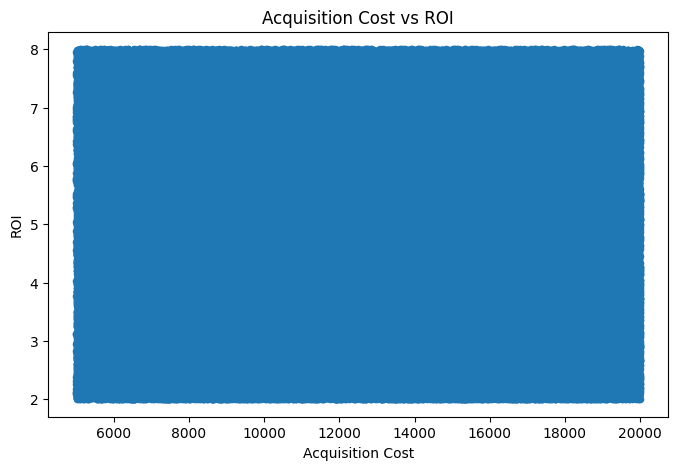

In [34]:
df.plot.scatter(
    x='Acquisition Cost',
    y='ROI',
    figsize=(8,5),
    title='Acquisition Cost vs ROI'
)

<Axes: title={'center': 'Acquisition Cost vs Conversion Rate'}, xlabel='Acquisition Cost', ylabel='Conversion Rate'>

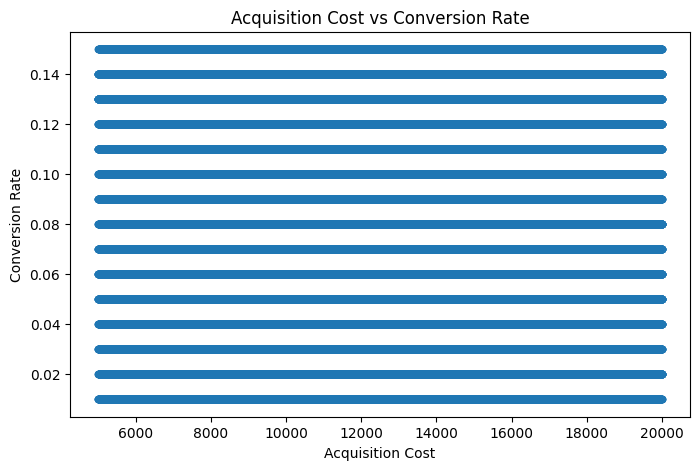

In [74]:
df.plot.scatter(
    x='Acquisition Cost',
    y='Conversion Rate',
    figsize=(8,5),
    title='Acquisition Cost vs Conversion Rate'
)

### Inisght:
Correlation analysis revealed almost no relationship between acquisition cost and campaign ROI or conversion performance. Scatterplot analysis further confirmed that higher acquisition costs did not consistently lead to stronger campaign profitability or improved conversion efficiency. This suggests that increased marketing spending alone may not guarantee better campaign outcomes within the current dataset.

### Q5. Which campaigns should be scaled, optimized, or discontinued based on overall performance?

In [36]:
campaign_summary = df.groupby('Campaign Type')[
    ['ROI','CTR','Engagement Score','Conversion Rate','Acquisition Cost']
].mean().round(2)

In [37]:
campaign_summary

,ROI,CTR,Engagement Score,Conversion Rate,Acquisition Cost
Campaign Type,,,,,
Display,5.01,14.13,5.51,0.08,12508.03
Email,4.99,13.95,5.50,0.08,12495.35
Influencer,5.01,14.03,5.48,0.08,12507.17
Search,5.01,13.99,5.49,0.08,12498.74
Social Media,4.99,14.10,5.50,0.08,12512.70


<Axes: title={'center': 'Campaign Type Performance'}, xlabel='Campaign Type'>

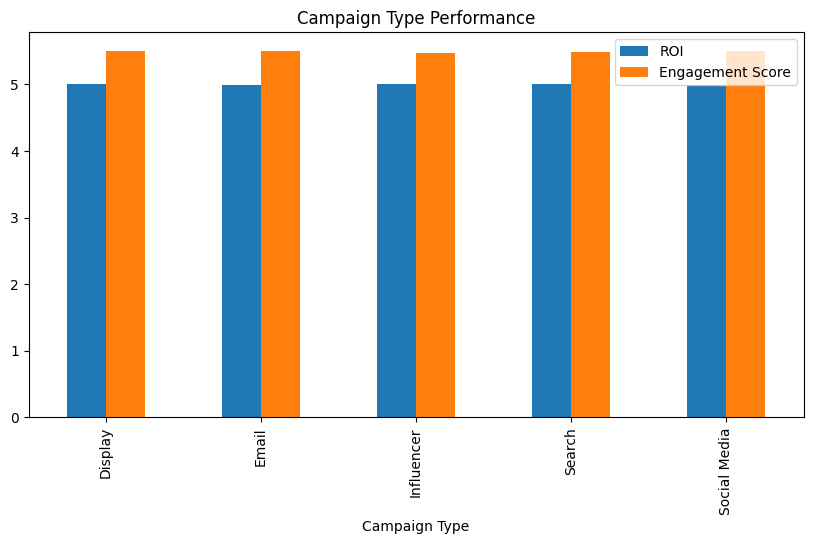

In [73]:
campaign_summary[['ROI','Engagement Score']].plot(
    kind='bar',
    figsize=(10,5),
    title='Campaign Type Performance'
)

### Inisght:
Campaign performance remained relatively consistent across different campaign types, with only marginal variations observed in ROI, engagement, CTR, and acquisition cost metrics. Display and Influencer campaigns demonstrated slightly stronger ROI performance, while Display and Social Media campaigns showed comparatively higher engagement and CTR levels. Overall, no campaign type showed significantly weak performance, suggesting that optimization opportunities may lie more in audience targeting and campaign execution strategies rather than campaign format selection alone.

### Statistical Analysis

In [39]:
correlation_matrix = df[
    ['ROI','CTR','Conversion Rate',
    'Acquisition Cost','Engagement Score',
     'Clicks','Impressions']
].corr()

In [40]:
correlation_matrix

,ROI,CTR,Conversion Rate,Acquisition Cost,Engagement Score,Clicks,Impressions
ROI,1.000000,-0.002116,-0.001143,0.004585,0.000588,-0.002040,0.002257
CTR,-0.002116,1.000000,-0.000049,-0.000899,-0.005747,0.506526,-0.657538
Conversion Rate,-0.001143,-0.000049,1.000000,0.000718,-0.000638,0.000269,-0.002834
Acquisition Cost,0.004585,-0.000899,0.000718,1.000000,-0.003218,0.000141,0.000329
Engagement Score,0.000588,-0.005747,-0.000638,-0.003218,1.000000,-0.001908,0.003030
Clicks,-0.002040,0.506526,0.000269,0.000141,-0.001908,1.000000,0.000033
Impressions,0.002257,-0.657538,-0.002834,0.000329,0.003030,0.000033,1.000000


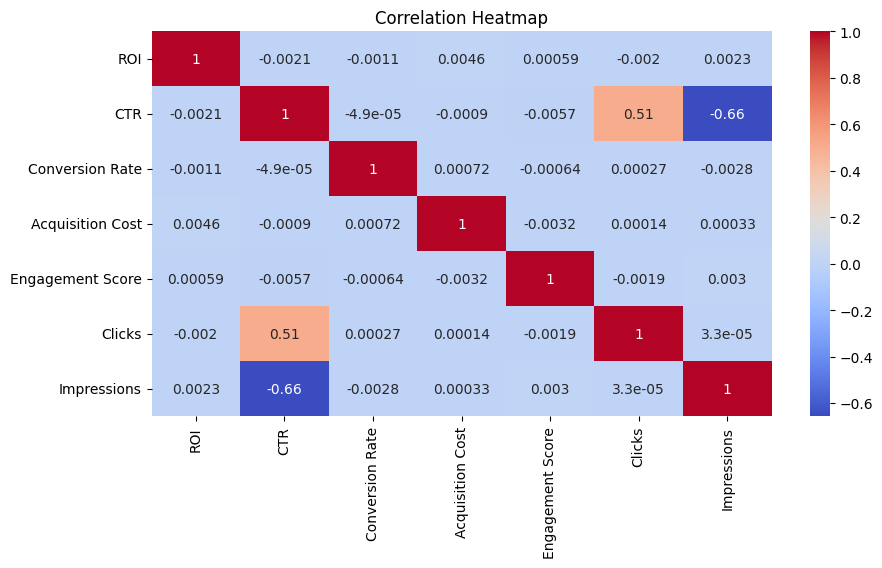

In [41]:
plt.figure(figsize=(10,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

### Inisght:
Correlation analysis revealed generally weak relationships among most campaign performance metrics, indicating that variables such as acquisition cost, ROI, engagement score, and conversion rate operated relatively independently within the dataset. CTR showed a moderate positive relationship with clicks (0.51), suggesting that campaigns generating more clicks tended to achieve stronger click-through performance. Additionally, impressions demonstrated a moderate negative correlation with CTR (-0.66), indicating that higher campaign reach did not necessarily translate into better engagement efficiency. Overall, the analysis suggests that increased campaign exposure alone may not guarantee stronger customer interaction or profitability.

### SQL Anlaysis

In [43]:
conn = sqlite3.connect('marketing_campaign')

In [44]:
df.to_sql("marketing_campaign",conn,index=False,if_exists="replace")

200000

### Q1. Which marketing channels generate the highest ROI and engagement performance?

In [55]:
query = """
SELECT
    "Channel Used",
    ROUND(AVG(ROI),2) AS Avg_ROI,
    ROUND(AVG("Engagement Score"),2) AS Avg_Engagement
FROM marketing_campaign
GROUP BY "Channel Used"
ORDER BY Avg_ROI DESC, Avg_Engagement DESC;
"""

pd.read_sql(query,conn)    

,Channel Used,Avg_ROI,Avg_Engagement
0,Facebook,5.02,5.50
1,Website,5.01,5.51
2,Email,5.00,5.49
3,Google Ads,5.00,5.49
4,Instagram,4.99,5.49
5,YouTube,4.99,5.48


### Inisght:
Marketing channels demonstrated relatively similar ROI and engagement performance, with Facebook and Website channels showing marginally stronger results compared to other platforms. Overall, channel-level performance differences remained limited across the dataset.

### Q2. Which campaign types achieve strong engagement but weaker conversion efficiency?

In [58]:
query = """
SELECT
     "Campaign Type",
     ROUND(AVG("Engagement Score"),2) AS Avg_Engagement,
     ROUND(aVG("Conversion Rate"),2) AS Avg_Conversion_Rate
FROM marketing_campaign
GROUP BY "Campaign Type"
HAVING AVG("Engagement Score") > 5.49
ORDER BY Avg_Engagement DESC;
"""

pd.read_sql(query,conn)

,Campaign Type,Avg_Engagement,Avg_Conversion_Rate
0,Display,5.51,0.08
1,Social Media,5.50,0.08
2,Email,5.50,0.08


#### Insight:
Display, Social Media, and Email campaigns achieved slightly higher engagement performance while maintaining similar conversion efficiency levels. This suggests that stronger engagement did not necessarily translate into improved conversion outcomes within the current dataset.

### Q3. Which target audience and customer segments respond most effectively to campaigns?

In [67]:
query = """
SELECT 
    "Target Audience",
    "Customer Segment",
    ROUND(AVG(ROI),2) AS Avg_ROI,
    ROUND(AVG("Engagement Score"),2) AS Avg_Engagement
FROM marketing_campaign
GROUP BY 
     "Target Audience",
     "Customer Segment"
ORDER BY Avg_ROI DESC
LIMIT 5;
"""

pd.read_sql(query,conn)

,Target Audience,Customer Segment,Avg_ROI,Avg_Engagement
0,Men 25-34,Outdoor Adventurers,5.04,5.51
1,Women 35-44,Tech Enthusiasts,5.04,5.44
2,All Ages,Foodies,5.03,5.46
3,Men 25-34,Health & Wellness,5.03,5.48
4,Men 25-34,Tech Enthusiasts,5.02,5.47


### Inisght:
Campaign response patterns remained relatively balanced across target audiences and customer segments. However, Men 25–34 Outdoor Adventurers and Women 35–44 Tech Enthusiasts demonstrated slightly stronger ROI performance, while Men 18–24 Foodies showed comparatively higher engagement levels.

### Q4. Does higher acquisition cost lead to better campaign ROI and conversion performance?

In [64]:
query = """
    SELECT
        "Campaign Type",
        ROUND(AVG("Acquisition Cost"),2) AS Avg_Acquisition_Cost,
        ROUND(AVG(ROI),2) AS Avg_ROI,
        ROUND(AVG("Conversion Rate"),2) AS Avg_Conversion_Rate
FROM marketing_campaign
GROUP BY "Campaign Type"
HAVING AVG("Acquisition Cost") > 
(
  SELECT AVG("Acquisition Cost")
  FROM marketing_campaign
);
"""

pd.read_sql(query,conn)

,Campaign Type,Avg_Acquisition_Cost,Avg_ROI,Avg_Conversion_Rate
0,Display,12508.03,5.01,0.08
1,Influencer,12507.17,5.01,0.08
2,Social Media,12512.70,4.99,0.08


### Insight:
Campaign types with above-average acquisition costs did not demonstrate significantly stronger ROI or conversion performance. This indicates that increased campaign spending alone may not guarantee better marketing effectiveness or conversion efficiency.

### Q5. Which campaigns should be scaled, optimized, or discontinued based on overall performance?

In [66]:
query = """
    SELECT
         "Campaign Type",
         ROUND(AVG(ROI),2) AS Avg_ROI,
         ROUND(AVG(CTR),2) AS Avg_CTR,
         ROUND(AVG("Engagement Score"),2) AS Avg_Engagement,

         RANK() OVER(
            ORDER BY AVG(ROI) DESC
        ) AS ROI_RANK
FROM marketing_campaign
GROUP BY "Campaign Type";
"""

pd.read_sql(query,conn)

,Campaign Type,Avg_ROI,Avg_CTR,Avg_Engagement,ROI_RANK
0,Influencer,5.01,14.03,5.48,1
1,Search,5.01,13.99,5.49,2
2,Display,5.01,14.13,5.51,3
3,Email,4.99,13.95,5.50,4
4,Social Media,4.99,14.10,5.50,5


### Insight:
Influencer, Search, and Display campaigns achieved slightly stronger ROI rankings compared to other campaign types. However, overall campaign performance remained broadly consistent, suggesting limited performance variation across campaign categories within the dataset.

### Key Findings
1. Marketing channels showed relatively stable ROI and engagement performance across platforms, with Facebook and Website campaigns performing slightly better than other channels.
2. Display and Social Media campaigns generated comparatively stronger engagement levels, although conversion performance remained almost similar across campaign types.
3. Customer segments and target audiences responded in a fairly balanced manner, with only small differences observed in ROI and engagement metrics.
4. Increasing acquisition cost did not consistently improve campaign ROI or conversion efficiency, indicating that higher spending alone was not enough to drive better campaign outcomes.
5. Correlation analysis showed weak relationships between most business KPIs, suggesting that campaign performance was influenced by multiple independent factors rather than a single dominant metric.

### Business Recommendations
1. Marketing teams should focus more on audience targeting and campaign optimization strategies instead of relying only on increased acquisition spending.
2. Campaigns generating higher engagement should be further optimized with stronger conversion-focused strategies to improve overall marketing effectiveness.
3. Channels demonstrating relatively stable ROI and engagement performance can be prioritized for future campaign planning and budget allocation.
4. Businesses should regularly monitor engagement, CTR, and conversion metrics together rather than evaluating campaign success using only one KPI.
5. Additional customer-level and behavioral data could help generate deeper marketing insights and support more advanced campaign optimization strategies.

### Conclusion

This project analyzed marketing campaign performance using Python, SQL, and statistical analysis techniques to evaluate campaign effectiveness across channels, campaign types, customer segments, and target audiences. The analysis showed that campaign performance remained relatively balanced across most dimensions, with only marginal differences observed in ROI, engagement, and conversion metrics. The project also highlighted the importance of combining business understanding, KPI analysis, SQL querying, and data visualization to support marketing decision-making and performance evaluation.